In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import torch
import warnings

from potential import Polymer
from util import TO_CM, ress
from generator import GeneratorBuilder, GeneratorTrainingScheduler
from aimmd import AIMMDNetwork, AIMMDCommittorTrainer
from transform_layers import PolymerTransformLayer, PolymerNormLayer

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10
})

In [ ]:
k_bias = 2.5
n_monomers = 7

transform_layer = PolymerTransformLayer(jacobian_regularization=1e-8)
norm_layer = PolymerNormLayer(Polymer.cartesian_to_internal(torch.tensor(np.loadtxt("samples/polymer_mcmc_beta_10_exchangerate_2_nout_1000_kbias_1500_nbiascenters_10.csv", delimiter=",")[:, :-1], dtype=torch.float32, device="cuda"))[0])

transform_layers = torch.nn.ModuleList([norm_layer, transform_layer])

aimmd_network = AIMMDNetwork(n_monomers*2-3, 3, [64, 32, 16], init_weights_zero=False, sigmoid=False, transform_layers=reversed(transform_layers), cv_function_without_sigmoid=True).to("cuda")
potential = Polymer(n_monomers, dimensions=2, cv_function=aimmd_network.cv_function, cv_gradient_function=aimmd_network.cv_gradient_function, k_bias=k_bias)

conditions_min = -8.0
conditions_max = 8.0

generator = GeneratorBuilder(potential=potential, n_blocks=8, n_hidden_layers=3, n_nodes=200, dimensions=potential.n_monomers*potential.dimensions-3, dimensions_conditions=1, 
                             conditions_min=conditions_min, conditions_max=conditions_max, transform_layers=transform_layers, reference_beta=1/0.1).build_generator(init_weights_dimensionality=False, cuda=True)

n_cycles = 40
n_epoch_aimmd = 50

aimmd_efficiency_threshold = 0

committor_target = "B"
committor_potential = potential
committor_q_A = 1.05
committor_q_B = 1.2
committor_timestep = 1e-4
committor_diffusion_coeff = 1.0
committor_max_steps = 1000000
aimmd_batch_size = 150
aimmd_lr = 1e-3

propagation_method = "mcmc"

weight_decay_aimmd = 1e-2

n_processes = 23
committor_batch_size = 25

mcmc_max_displacement = 0.4
md_steps = 3000
md_potential = potential
md_timestep = 1e-4
md_diffusion_coeff = 1.0

pool_size = 2 # Use data of last n cycles in training

n_samples_stable_states = 1000 # Number of samples per stable state
n_samples_tps = 4000 # Number of samples on transition paths

n_samples = n_samples_stable_states*2 + n_samples_tps

n_out_samples = 1000
out_samples_bias_centers = np.linspace(-6, 6, 7)

x_sample_beta = 10.0

initial_x_samples_stable_states = np.loadtxt("samples/polymer_stable_state_nsamples_20000_qa_1.05_qb_1.2.csv", delimiter=",")
initial_x_samples_cv_stable_states = Polymer.radius_of_gyration_2D(initial_x_samples_stable_states)
samples_in_A = initial_x_samples_stable_states[initial_x_samples_cv_stable_states < committor_q_A][:n_samples_stable_states]
samples_in_B = initial_x_samples_stable_states[initial_x_samples_cv_stable_states > committor_q_B][:n_samples_stable_states]
assert len(samples_in_A) == n_samples_stable_states, f"Not enough samples in data set in stable state A ({len(samples_in_A)}/{n_samples_stable_states})"
assert len(samples_in_B) == n_samples_stable_states, f"Not enough samples in data set in stable state B ({len(samples_in_B)}/{n_samples_stable_states})"
initial_outcomes_stable_states = np.ones((n_samples_stable_states*2, 2))
initial_outcomes_stable_states[n_samples_stable_states:] = -1 # Assumes target state is B
if committor_target == "A":
    initial_outcomes_stable_states *= -1 # If it is A, flip the signs of the initial outcomes

initial_x_samples_tps = np.loadtxt("samples/polymer_sps_nsamples_50000_target_B_nout_1_trajectoryoutfrequency_10_beta_10.0_maxlength_10000_qa_1.05_qb_1.2_timestep_0.0001_diffusioncoeff_1.0.csv", delimiter=",")[:n_samples_tps] # Four columns, first two are x and y positions of shooting points, second two are outcomes of two-way shooting
assert len(initial_x_samples_tps) == n_samples_tps, f"Not enough samples in data set on tps ({len(initial_x_samples_tps)}/{n_samples_tps})"
initial_outcomes_tps = initial_x_samples_tps[:, -2:]
initial_x_samples_tps = initial_x_samples_tps[:, :-2]

initial_x_samples = np.vstack([samples_in_A, samples_in_B, initial_x_samples_tps])
initial_outcomes = np.vstack([initial_outcomes_stable_states, initial_outcomes_tps])

shuffle_indices = np.random.choice(n_samples, n_samples, replace=False)
initial_outcomes = initial_outcomes[shuffle_indices]
initial_x_samples = torch.tensor(initial_x_samples[shuffle_indices], dtype=torch.float32)

trainer = AIMMDCommittorTrainer(aimmd_network, generator, committor_potential, committor_q_A, committor_q_B, committor_target, md_potential, md_timestep,
                                md_diffusion_coeff, Polymer.radius_of_gyration_2D, {}, committor_timestep, committor_diffusion_coeff, mcmc_max_displacement)

generator_training_scheduler = GeneratorTrainingScheduler(defaults={"n_out": 0, "decay": "none", "push_to_gpu": True, "beta_min": 1/0.3, "beta_max": 1/0.05, "x_sample_betas": x_sample_beta,
                                                                    "batch_size": 250, "conditions_per_batch": 50})


generator_training_scheduler.schedule_task(n_epochs=100, lr=5e-4, w_KL=0)
generator_training_scheduler.schedule_task(n_epochs=50, lr=1e-4, w_KL=1e-4, e_high_initial=1e0, e_high_plateau=1e0)
generator_training_scheduler.schedule_task(n_epochs=25, lr=1e-4, w_KL=1e-3, e_high_initial=1e0, e_high_plateau=1e0)

In [ ]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    out_samples, out_weights, out_samples_bias_centers = trainer.train(initial_x_samples, n_processes, n_cycles, generator_training_scheduler, n_epoch_aimmd, aimmd_batch_size, aimmd_efficiency_threshold, 
                                                        committor_batch_size, md_steps, pool_size, conditions_min=conditions_min, conditions_max=conditions_max, 
                                                        initial_outcomes=initial_outcomes, aimmd_lr=aimmd_lr, n_out_samples=n_out_samples, propagation_method=propagation_method,
                                                        weight_decay_aimmd=weight_decay_aimmd, x_sample_beta=x_sample_beta, preprocess_training_data=Polymer.constrain_first_angle_cartesian, 
                                                        committor_max_steps=committor_max_steps, out_samples_bias_centers=out_samples_bias_centers)

In [ ]:
torch.save(trainer, "trainers/polymer.pt")

np.save("trainers/polymer_out_weights.npy", out_weights)
np.save("trainers/polymer_out_samples_bias_centers.npy", out_samples_bias_centers)

# Loading trainer and training output

In [2]:
trainer = torch.load("trainers/polymer.pt", weights_only=False)

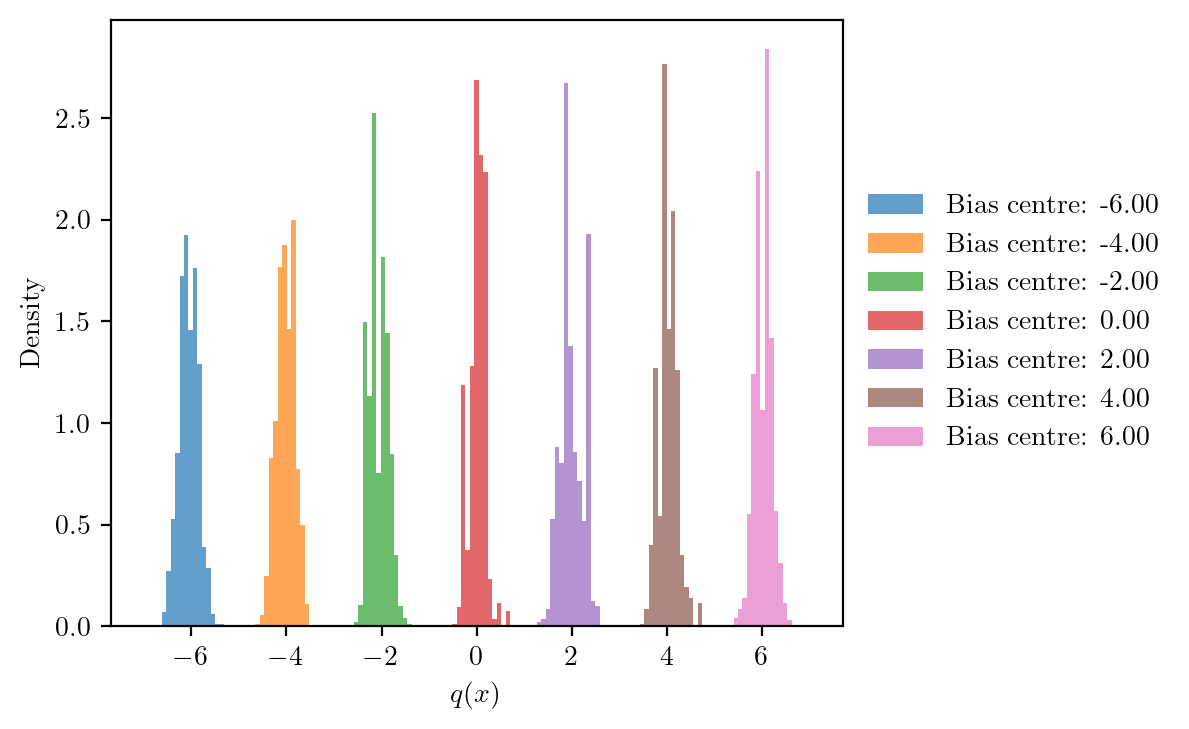

In [ ]:
generator = trainer.generator
aimmd_network = trainer.aimmd_network

beta = 10.0

example_bias_centers = np.linspace(-6, 6, 7)
samples = []
weight_list = []

for example_bias_center in example_bias_centers:
    example_input = generator.generate_z_samples(500000, betas=beta)
    example_input = torch.hstack([example_input, example_input.new_ones((len(example_input), 1))*example_bias_center])

    with torch.inference_mode():
        generated_samples, log_R_zx = generator.F_zx(example_input)

        weights = generator.get_weights(generated_samples, log_R_zx, example_input, beta=beta, normalize=True, drop_invalid_samples=True)
        weights = weights.detach().cpu().numpy()

        chosen_indices = np.random.choice(len(generated_samples), len(generated_samples), p=weights)
        samples.append(generated_samples[chosen_indices])
        weight_list.append(weights)

        effective_sample_size = ress(weights)
        print(effective_sample_size)

fig, ax = plt.subplots(1, 1, dpi=200, figsize=(12*TO_CM, 10*TO_CM))

for i, sample in enumerate(samples):
    with torch.inference_mode():
        committor_guesses = aimmd_network.forward(Polymer.constrain_first_angle_cartesian(sample[:, :-1])).detach().cpu().numpy()
    densities, _, hist = ax.hist(committor_guesses, density=True, bins=np.linspace(-7, 7, 150), weights=weight_list[i], label=f"Bias centre: {example_bias_centers[i]:0.2f}", alpha=0.7)

ax.set_xlabel(r"$q(x)$")
ax.set_ylabel("Density")

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.show()

In [ ]:
np.save("trainers/polymer_example_bias_centers.npy", np.array(example_bias_centers))
np.save("trainers/polymer_samples.npy", np.array([sample.detach().cpu().numpy() for sample in samples]))
np.save("trainers/polymer_weight_list.npy", np.array(weight_list))

In [3]:
example_bias_centers = np.load("trainers/polymer_example_bias_centers.npy")
samples = torch.from_numpy(np.load("trainers/polymer_samples.npy")).to(trainer.device)
weight_list = np.load("trainers/polymer_weight_list.npy")

In [4]:
example_bias_centers = np.linspace(0, 1, 7)

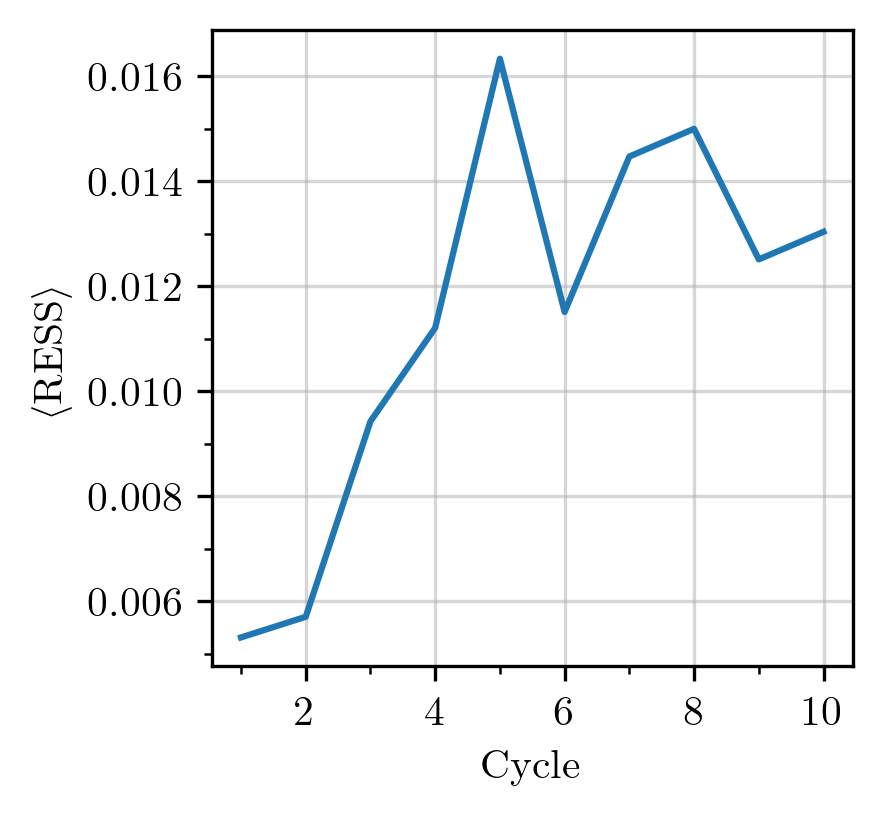

In [8]:
out_weights = np.load("trainers/polymer_out_weights.npy")
out_samples_bias_centers = np.load("trainers/polymer_out_samples_bias_centers.npy")

n_cycles = out_weights.shape[1]

instantaneous_ress_per_bias_center = np.empty((len(out_samples_bias_centers), n_cycles))

for out_samples_bias_center in range(len(out_samples_bias_centers)):
    for cycle in range(n_cycles):
        instantaneous_ress_per_bias_center[out_samples_bias_center, cycle] = ress(out_weights[out_samples_bias_center, cycle])

instantaneous_mean_ress = np.mean(instantaneous_ress_per_bias_center, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(7*TO_CM, 7*TO_CM), dpi=300)

ax.plot(np.arange(1, len(instantaneous_mean_ress) + 1), instantaneous_mean_ress)

ax.set_xlabel("Cycle")
ax.set_ylabel(r"$\langle$RESS$\rangle$")

ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.grid(alpha=0.5)

plt.show()

In [ ]:
from mcmc import polymer_biased_mcmc_2D

inv_sig = lambda p: -np.log(1/p - 1)
sig = lambda q: 1/(np.exp(-q) + 1)

bias_centers = np.linspace(-6, 6, 7)

trainer = torch.load("trainers/polymer.pt", weights_only=False)
generator = trainer.generator
aimmd_network = trainer.aimmd_network

aimmd_network.sigmoid = True

potential = Polymer(7, dimensions=2, cv_function=aimmd_network.cv_function, cv_gradient_function=aimmd_network.cv_gradient_function, k_bias=2.5)

beta = 10.0

results = []

for bias_center in bias_centers:
    example_input = generator.generate_z_samples(2500, betas=beta)
    example_input = torch.hstack([example_input, example_input.new_ones((len(example_input), 1))*sig(bias_center)])

    with torch.inference_mode():
        samples_r, _ = generator.F_zx(example_input)

    samples_r = samples_r.detach().cpu().numpy()[:, :-1]

    n_samples = 0
    n_equil = 5000

    samples_r = polymer_biased_mcmc_2D(samples_r, potential, n_samples, bias_center, enhanced_sampling=True, max_displacement=0.4, beta=beta, n_out=1, n_equil=n_equil, exchange_rate=0, progress=True)[0]
    results.append(samples_r.copy())

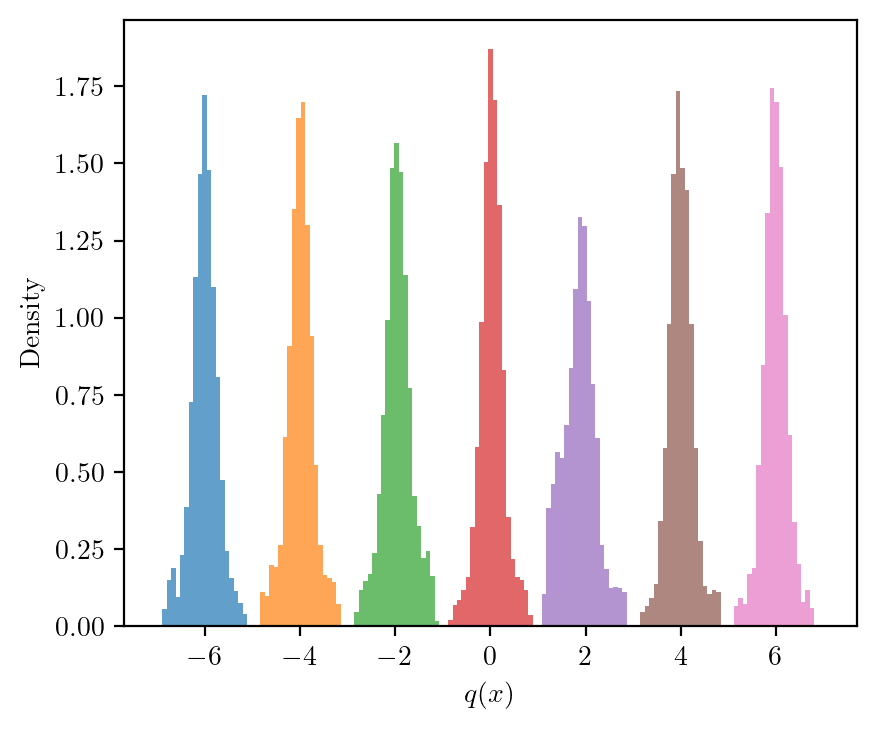

In [6]:
fig, ax = plt.subplots(1, 1, dpi=200, figsize=(12*TO_CM, 10*TO_CM))

for bias_center, samples_r in zip(bias_centers, results):
    with torch.inference_mode():
        q_guesses = aimmd_network.forward(Polymer.constrain_first_angle_cartesian(torch.from_numpy(samples_r).float().cuda())).detach().cpu().numpy()
    q_guesses = q_guesses[np.abs(q_guesses - bias_center) < 0.84]
    densities, _, hist = ax.hist(q_guesses, density=True, bins=np.linspace(-7, 7, 150), alpha=0.7)

ax.set_xlabel("$q(x)$")
ax.set_ylabel("Density")

plt.show()

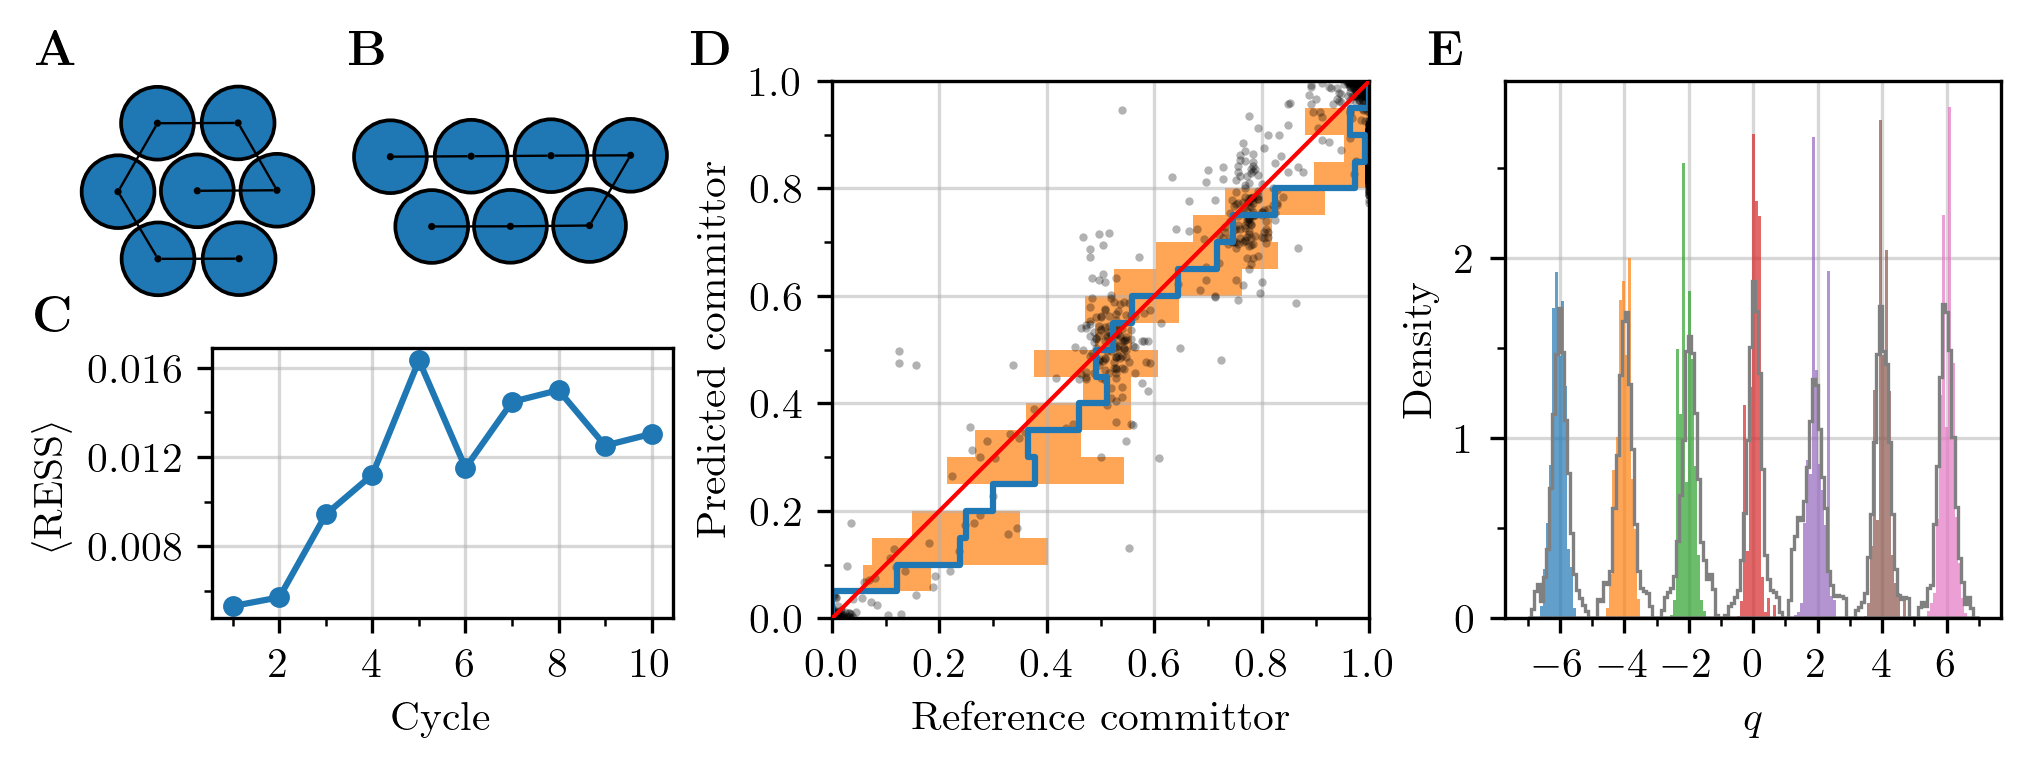

In [ ]:
import re
import xml.etree.ElementTree as ET
from matplotlib.patches import Circle

A_SVG, B_SVG = "images/A.svg", "images/B.svg"

SVG_NS, INKSCAPE_NS = "{http://www.w3.org/2000/svg}", "{http://www.inkscape.org/namespaces/inkscape}"
NUMBER = r"[-+]?[\d.]+(?:[eE][-+]?\d+)?"
MONOMER_COLOUR, STROKE_MONOMER, STROKE_BOND = "#1f77b4", 0.5, 0.3137 # Stroke widths in SVG user units


def svg_translation(node):
    """Reads the translate() transform of an SVG node, if it has one"""
    match = re.match(rf"translate\(({NUMBER})(?:[,\s]+({NUMBER}))?\)", node.get("transform") or "")
    return (float(match.group(1)), float(match.group(2) or 0.0)) if match else (0.0, 0.0)


def read_polymer_svg(path):
    """Reads the monomer circles and the bonds of an Inkscape polymer sketch, in SVG user units

    Parameters
    ----------
    path : str
        Path to the SVG file

    Returns
    -------
    dict
        Width and height of the view box, the monomer circles, the small circles marking the monomer
        centres and the bonds, each as (x, y, radius) resp. ((x_start, x_end), (y_start, y_end))
    """
    root = ET.parse(path).getroot()
    circles, bonds = [], []

    def walk(node, tx, ty):
        for child in node:
            dx, dy = svg_translation(child)
            x, y = tx + dx, ty + dy
            if child.tag == SVG_NS + "circle":
                circles.append((float(child.get("cx")) + x, float(child.get("cy")) + y, float(child.get("r"))))
            elif child.tag == SVG_NS + "path":
                d = child.get("d")
                p = [float(value) for value in re.findall(NUMBER, d)]
                x_start, y_start = p[0] + x, p[1] + y
                x_end, y_end = (x_start + p[2], y_start + p[3]) if d[0] == "m" else (p[2] + x, p[3] + y)
                bonds.append(((x_start, x_end), (y_start, y_end)))
            elif child.tag == SVG_NS + "g":
                walk(child, x, y)

    layer = root.find(f".//{SVG_NS}g[@{INKSCAPE_NS}groupmode='layer']")
    walk(layer, *svg_translation(layer))

    width, height = (float(value) for value in root.get("viewBox").split()[2:])
    r_monomer = max(circle[2] for circle in circles)

    return dict(width=width, height=height, bonds=bonds,
                monomers=[circle for circle in circles if circle[2] == r_monomer],
                centres=[circle for circle in circles if circle[2] < r_monomer])


def draw_polymer(ax, sketch, y_span, pad):
    """Draws a sketch read by read_polymer_svg onto the given axes

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to draw on
    sketch : dict
        Sketch as returned by read_polymer_svg
    y_span : float
        Height of the y range in SVG user units. Passing the same value for every sketch puts all of
        them at the same scale, as long as their axes are equally high
    pad : float
        Blank margin left and right of the view box, in SVG user units

    Returns
    -------
    list
        The artists whose stroke width still has to be converted from SVG user units into points,
        to be handed to set_stroke_widths once the figure is laid out
    """
    strokes = []

    for cx, cy, r in sketch["monomers"]:
        circle = Circle((cx, cy), r, facecolor=MONOMER_COLOUR, edgecolor="black", zorder=1)
        ax.add_patch(circle)
        strokes.append((circle, STROKE_MONOMER))

    for cx, cy, r in sketch["centres"]:
        ax.add_patch(Circle((cx, cy), r, facecolor="black", edgecolor="none", zorder=2))

    for xs, ys in sketch["bonds"]:
        line, = ax.plot(xs, ys, color="black", solid_capstyle="butt", zorder=3)
        strokes.append((line, STROKE_BOND))

    ax.set_xlim(-pad, sketch["width"] + pad)
    ax.set_ylim(sketch["height"]/2 + y_span/2, sketch["height"]/2 - y_span/2)
    ax.set_aspect("equal")
    ax.set_axis_off()

    return strokes


def set_stroke_widths(ax, strokes):
    """Converts SVG stroke widths (user units) into points, matching the size of the axes on the page"""
    ax.figure.canvas.draw()
    x_min, x_max = ax.get_xlim()
    points_per_unit = ax.get_window_extent().width*72/ax.figure.dpi/(x_max - x_min)

    for artist, width in strokes:
        artist.set_linewidth(width*points_per_unit)

committor_estimates = np.loadtxt("committor_estimates/polymer_gyration_ntrajectories_250_beta_10.0_qa_1.05_qb_1.2_target_B_timestep_0.0001_diffusioncoeff_1.0.csv", delimiter=",")

with torch.inference_mode():
    aimmd_guesses = trainer.aimmd_network.forward_with_sigmoid(torch.from_numpy(Polymer.constrain_first_angle_cartesian(committor_estimates[:, :-1])).float().cuda()).detach().cpu().numpy()
aimmd_guesses = aimmd_guesses.flatten()

reference_committors = committor_estimates[:, -1]

avg_bins = 20

avg_bin_edges = np.linspace(np.min(aimmd_guesses), np.max(aimmd_guesses), avg_bins + 1)
bin_averages = []
bin_stds = []
bin_bounds = []

for i in range(len(avg_bin_edges) - 1):
    bin_start = avg_bin_edges[i]
    bin_end = avg_bin_edges[i+1]

    relevant_reference_pbs = reference_committors[(aimmd_guesses >= bin_start) & (aimmd_guesses < bin_end)]
    bin_averages.append(np.mean(relevant_reference_pbs))
    bin_stds.append(np.std(relevant_reference_pbs))
    bin_bounds += [bin_start, bin_end]


density_bias_centers = np.linspace(-6, 6, 7)

out_weights = np.load("trainers/polymer_out_weights.npy")
out_samples_bias_centers = np.load("trainers/polymer_out_samples_bias_centers.npy")

n_cycles = out_weights.shape[1]

instantaneous_ress_per_bias_center = np.empty((len(out_samples_bias_centers), n_cycles))

for out_samples_bias_center in range(len(out_samples_bias_centers)):
    for cycle in range(n_cycles):
        instantaneous_ress_per_bias_center[out_samples_bias_center, cycle] = ress(out_weights[out_samples_bias_center, cycle])

instantaneous_mean_ress = np.mean(instantaneous_ress_per_bias_center, axis=0)

FIG_W, FIG_H = 17.0, 6.15
PANEL_B, PANEL_S = 1.05, 4.55
RESS_X, RESS_W, RESS_GAP = 1.70, 3.90, 0.40
SCATTER_X = 6.95
DENSITY_X, DENSITY_W = 12.65, 4.20
POLY_X, POLY_W, POLY_GAP, POLY_PAD = 0.55, 5.05, 0.25, 0.5
LETTER_X = 0.20

sketch_A, sketch_B = read_polymer_svg(A_SVG), read_polymer_svg(B_SVG)

y_span = max(sketch_A["height"], sketch_B["height"]) + 2*POLY_PAD
width_A, width_B = sketch_A["width"] + 2*POLY_PAD, sketch_B["width"] + 2*POLY_PAD
scale = (POLY_W - POLY_GAP)/(width_A + width_B)
POLY_H = y_span*scale
POLY_B = PANEL_B + PANEL_S - POLY_H

fig = plt.figure(figsize=(FIG_W*TO_CM, FIG_H*TO_CM), dpi=300)
add_axes = lambda x, y, w, h: fig.add_axes((x/FIG_W, y/FIG_H, w/FIG_W, h/FIG_H))

ax_A = add_axes(POLY_X, POLY_B, width_A*scale, POLY_H)
ax_B = add_axes(POLY_X + width_A*scale + POLY_GAP, POLY_B, width_B*scale, POLY_H)
strokes_A = draw_polymer(ax_A, sketch_A, y_span, POLY_PAD)
strokes_B = draw_polymer(ax_B, sketch_B, y_span, POLY_PAD)

ax_ress = add_axes(RESS_X, PANEL_B, RESS_W, POLY_B - RESS_GAP - PANEL_B)

ax_ress.plot(np.arange(1, len(instantaneous_mean_ress) + 1), instantaneous_mean_ress, marker='o', markersize=4)

ax_ress.set_xlabel("Cycle")
ax_ress.set_ylabel(r"$\langle$RESS$\rangle$")
ax_ress.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(5, integer=True))
ax_ress.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(4))

ax_scatter = add_axes(SCATTER_X, PANEL_B, PANEL_S, PANEL_S)

ax_scatter.scatter(reference_committors, aimmd_guesses, s=4, lw=0, color="black", alpha=0.3, zorder=1)
ax_scatter.plot([0, 1], [0, 1], lw=1, color="red", zorder=3)

ax_scatter.plot(np.repeat(bin_averages, 2), bin_bounds, zorder=2)

bin_averages = np.asarray(bin_averages)
bin_stds = np.asarray(bin_stds)

lower = np.repeat(bin_averages - bin_stds, 2)
upper = np.repeat(bin_averages + bin_stds, 2)

ax_scatter.fill_betweenx(bin_bounds, lower, upper, color="tab:orange", alpha=0.7, linewidth=0, zorder=0)


ax_scatter.set_xlim((0, 1))
ax_scatter.set_ylim((0, 1))
ax_scatter.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.2))
ax_scatter.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.2))
ax_scatter.set_xlabel("Reference committor")
ax_scatter.set_ylabel("Predicted committor")

ax_density = add_axes(DENSITY_X, PANEL_B, DENSITY_W, PANEL_S)

for i, sample in enumerate(samples):
    with torch.inference_mode():
        committor_guesses = aimmd_network.forward(Polymer.constrain_first_angle_cartesian(sample[:, :-1])).detach().cpu().numpy()
    densities, _, hist = ax_density.hist(committor_guesses, density=True, bins=np.linspace(-7, 7, 150), weights=weight_list[i], alpha=0.7)

for i, reference_sample in enumerate(results):
    with torch.inference_mode():
        q_guesses = aimmd_network.forward(Polymer.constrain_first_angle_cartesian(torch.from_numpy(reference_sample).float().cuda())).detach().cpu().numpy()
    q_guesses = q_guesses[np.abs(q_guesses - density_bias_centers[i]) < 0.84]
    ax_density.hist(q_guesses, density=True, bins=np.linspace(-7, 7, 150), histtype="step", color=f"gray", lw=0.8, label=None if i != len(results) - 1 else "Reference")

ax_density.set_xlabel(r"$q$")
ax_density.set_ylabel("Density")
ax_density.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))

ax_density.set_xticks(density_bias_centers, [f"${centre:g}$" for centre in density_bias_centers])

for ax in (ax_ress, ax_scatter, ax_density):
    ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    ax.grid(alpha=0.5)
    ax.set_axisbelow(True)

panel_letters = ((LETTER_X, POLY_B + POLY_H, "A"),
                 (POLY_X + width_A*scale + POLY_GAP, POLY_B + POLY_H, "B"),
                 (LETTER_X, POLY_B - RESS_GAP, "C"),
                 (5.75, PANEL_B + PANEL_S, "D"),
                 (12.00, PANEL_B + PANEL_S, "E"))

for x, y, letter in panel_letters:
    fig.text(x/FIG_W, (y + 0.06)/FIG_H, rf"\textbf{{{letter}}}", va="bottom", fontdict={'fontsize': 12})

set_stroke_widths(ax_A, strokes_A)
set_stroke_widths(ax_B, strokes_B)

plt.show()
